# Analyst-lab Africa Week 8 : Comprehensive Heart Disease Dataset

This is my capstoone project for the Analyst-lab Africa internship it is to demostrate the practical skills that i have acquired throughout the internship by completing an end to end Machine Learning Project using real-world data to solve a real-world problem.

## The Problem
Heart disease remains one of the leading causes of death worldwide, often progressing silently before a life-threatening event occurs. Many cases go undetected until it's too late. This project analyzes clinical and diagnostic data — including chest pain patterns, blood pressure, cholesterol, and stress test results — to uncover patterns behind heart disease, aiming to build a model that predicts a patient's risk early

## Why this problem
Heart disease is a leading precursor to life-threatening cardiac events, including heart attacks. This project builds a model that can predict whether a patient is likely to have underlying heart disease based on clinical and diagnostic indicators. Early detection like this can help influence doctors' decisions and prompt further testing or intervention before a critical event occurs.

## The Expected Impact
This notebook doesn't solve the problem completely — this model  is a proof of concept model on a well-known benchmark dataset its not a production-ready diagnostic tool.

## The data
Source: [Heart Disease Dataset (Comprehensive) — IEEE DataPort](https://ieee-dataport.org/open-access/heart-disease-dataset-comprehensive) (also mirrored on Kaggle as `heart-statlog-cleveland-hungary-final`).

**Important — access note:** this dataset is gated behind an IEEE DataPort / Kaggle login, so it can't be downloaded automatically in this notebook the way the UCI Cleveland zip was. Download `heart_statlog_cleveland_hungary_final.csv` manually and place it in the same folder as this notebook (or update `DATA_PATH` below) before running.

The dataset has 12 columns (11 features + target)

- **age**: Patient's age (years)
- **sex**: 1 = male, 0 = female
- **chest_pain_type**: 1 = typical angina, 2 = atypical angina, 3 = non-anginal pain, 4 = asymptomatic
- **resting_bp_s**: Resting blood pressure (mmHg)
- **cholesterol**: Serum cholesterol (mg/dL)
- **fasting_blood_sugar**: 1 = fasting blood sugar > 120 mg/dL, 0 = otherwise
- **resting_ecg**: 0 = normal, 1 = ST-T wave abnormality, 2 = left ventricular hypertrophy
- **max_heart_rate**: Maximum heart rate achieved during exercise
- **exercise_angina**: 1 = exercise-induced angina, 0 = no
- **oldpeak**: ST depression induced by exercise relative to rest
- **st_slope**: Documented as 1 = upsloping, 2 = flat, 3 = downsloping — **but the raw data also contains a 4th, undocumented value (0)**, which we investigate and handle explicitly below
- **target**: 1 = heart disease present, 0 = absent

### Known data-quality issues to handle (flagged in advance from prior research into this dataset)
1. **Duplicate records** — reports of ~272 duplicate rows, since the Statlog portion overlaps with data already present elsewhere in the merge.
2. **Placeholder zeros instead of true missing values** — `cholesterol` reportedly has ~172 zero values (~14.5% of rows), which are very unlikely to be real readings (a living patient can't have 0 mg/dL cholesterol) and are more likely unrecorded values coded as 0.
3. **Undocumented category in `st_slope`** — a value of `0` appears in the raw data despite documentation only describing 1/2/3.
4. **Class balance** — needs checking, since 5 merged sources may not have identical positive/negative rates.

### Metric
we evaluate using multiple classification metrics (balanced accuracy, F1, ROC-AUC, precision, recall) via stratified k-fold cross-validation, since a single metric or single train/test split can be misleading.

### Task Breakdown
1. Exploratory Data Analysis (EDA)
2. Data Preprocessing (handling the issues flagged above)
3. Model Building (Logistic Regression, Random Forest, XGBoost — same as Cleveland notebook, for direct comparison)
4. Model Evaluation (same metric suite, compared against Cleveland results)


# Phase 1: Importing Libraries and Loading Data

In [2]:
%pip install Xgboost
%pip install optuna
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import imblearn
import sklearn

print(f"imblearn version: {imblearn.__version__}")
print(f"sklearn version: {sklearn.__version__}")

imblearn version: 0.14.1
sklearn version: 1.6.1


In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import balanced_accuracy_score, f1_score, roc_auc_score, precision_score, recall_score
import xgboost as xgb

import joblib
import optuna
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.ensemble import BalancedBaggingClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

In [5]:
# NOTE: This dataset is gated behind an IEEE DataPort / Kaggle login, so it can't be
# fetched automatically like the UCI Cleveland zip. Download the CSV manually from:
#   https://ieee-dataport.org/open-access/heart-disease-dataset-comprehensive
# or the Kaggle mirror:
#   https://www.kaggle.com/datasets/sid321axn/heart-statlog-cleveland-hungary-final
# and place it alongside this notebook (or update DATA_PATH below).

DATA_PATH = "/kaggle/input/datasets/sid321axn\
/heart-statlog-cleveland-hungary-final/heart_statlog_cleveland_hungary_final.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Could not find '{DATA_PATH}'. Please download the dataset manually "
        "(login required) and place the CSV in this notebook's directory, "
        "or update DATA_PATH to point to it."
    )

data = pd.read_csv(DATA_PATH)

# standardize column names in case the source file uses a different casing/spacing
data.columns = (
    data.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(data.columns.tolist())
data.head()

['age', 'sex', 'chest_pain_type', 'resting_bp_s', 'cholesterol', 'fasting_blood_sugar', 'resting_ecg', 'max_heart_rate', 'exercise_angina', 'oldpeak', 'st_slope', 'target']


,age,sex,chest_pain_type,resting_bp_s,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,st_slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0


In [6]:
d_shape = data.shape
print(f"The shape of the data is Row: {d_shape[0]} and Column: {d_shape[1]}")
print("=" * 60)
data.info()

The shape of the data is Row: 1190 and Column: 12
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1190 non-null   int64  
 1   sex                  1190 non-null   int64  
 2   chest_pain_type      1190 non-null   int64  
 3   resting_bp_s         1190 non-null   int64  
 4   cholesterol          1190 non-null   int64  
 5   fasting_blood_sugar  1190 non-null   int64  
 6   resting_ecg          1190 non-null   int64  
 7   max_heart_rate       1190 non-null   int64  
 8   exercise_angina      1190 non-null   int64  
 9   oldpeak              1190 non-null   float64
 10  st_slope             1190 non-null   int64  
 11  target               1190 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 111.7 KB


# Phase 2: Exploratory Data Analysis

Before touching any preprocessing, we check the specific issues flagged for this dataset: duplicates, placeholder zeros, the undocumented `st_slope` category, and class balance.

In [7]:
# --- 1. Duplicate records ---
n_duplicates = data.duplicated().sum()
print(f"Number of exact duplicate rows: {n_duplicates}")
print(f"Percentage of dataset: {n_duplicates / len(data) * 100:.2f}%")

Number of exact duplicate rows: 272
Percentage of dataset: 22.86%


In [8]:
# --- 2. Placeholder zeros in cholesterol (and a quick check on resting_bp_s too) ---
zero_chol = (data['cholesterol'] == 0).sum()
zero_bp = (data['resting_bp_s'] == 0).sum()

print(f"Cholesterol == 0: {zero_chol} rows ({zero_chol/len(data)*100:.2f}%)")
print(f"Resting BP == 0: {zero_bp} rows ({zero_bp/len(data)*100:.2f}%)")

# A resting blood pressure or cholesterol of 0 is not physiologically possible in a living
# patient, so these are almost certainly missing values encoded as 0, not real readings.

Cholesterol == 0: 172 rows (14.45%)
Resting BP == 0: 1 rows (0.08%)


In [9]:
# --- 3. Undocumented category in st_slope ---
print(data['st_slope'].value_counts().sort_index())
print()
print(data.groupby('st_slope')['target'].mean())

# Documentation only describes values 1 (up), 2 (flat), 3 (down) -- check what 0 looks like
# and how many rows carry it before deciding how to treat it.

st_slope
0      1
1    526
2    582
3     81
Name: count, dtype: int64

st_slope
0    1.000000
1    0.209125
2    0.788660
3    0.728395
Name: target, dtype: float64


target
1    0.528571
0    0.471429
Name: proportion, dtype: float64


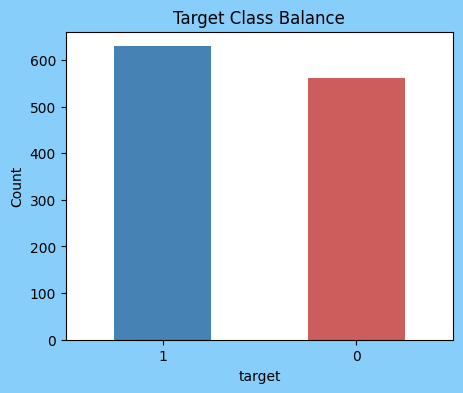

In [10]:
# --- 4. Class balance ---
print(data['target'].value_counts(normalize=True))

fig, ax = plt.subplots(facecolor='lightskyblue', figsize=(5, 4))
data['target'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'indianred'])
plt.title("Target Class Balance")
plt.xlabel("target")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [11]:
def plot_dist(df, column):
    """
    plots the distribution of features in a given column
    arg:
        df: dataframe
        column: given column
    """
    dist_count = df[column].value_counts()
    dist_index = dist_count.index
    dist_values = dist_count.values

    fig, ax = plt.subplots(facecolor='lightskyblue', figsize=(7, 5))
    dist_count.plot(kind = 'bar', ax = ax,)
    plt.title(f"Bar Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.show()


def plot_hist(df, column, bins=20):
    """
    plots the histogram of a given numerical column
    arg:
        df: dataframe
        column: given column
        bins: number of bins for the histogram (default 20)
    """
    data_col = df[column].dropna()

    fig, ax = plt.subplots(facecolor='lightskyblue', figsize=(7, 5))
    counts, bin_edges, _ = ax.hist(data_col, bins=bins, edgecolor='black', alpha=0.7)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    ax.plot(bin_centers, counts, color='red', marker='o', linewidth=2)

    plt.title(f"Histogram of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

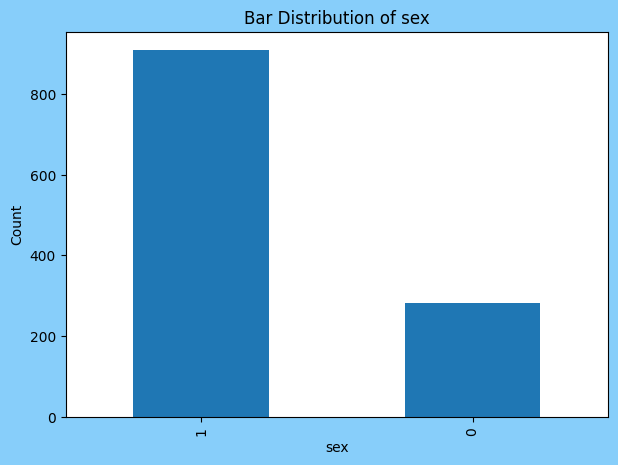

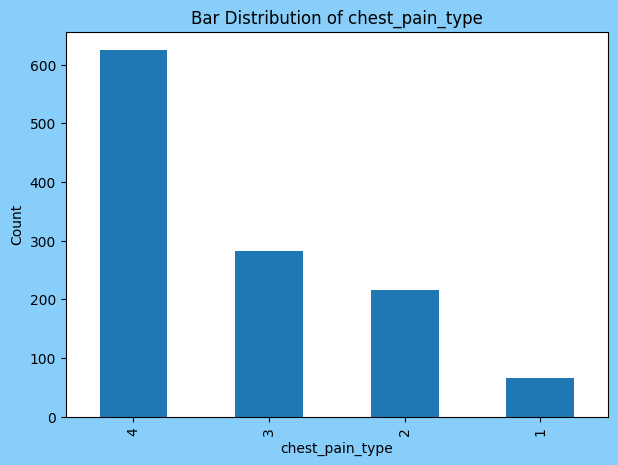

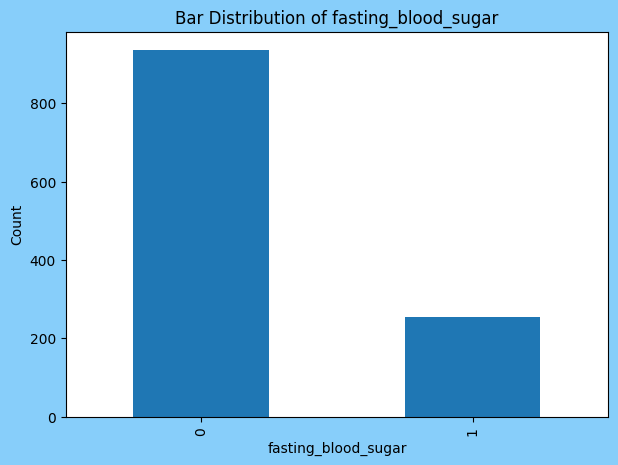

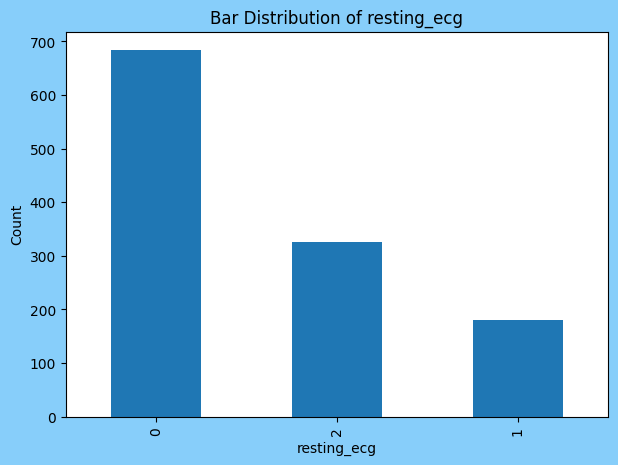

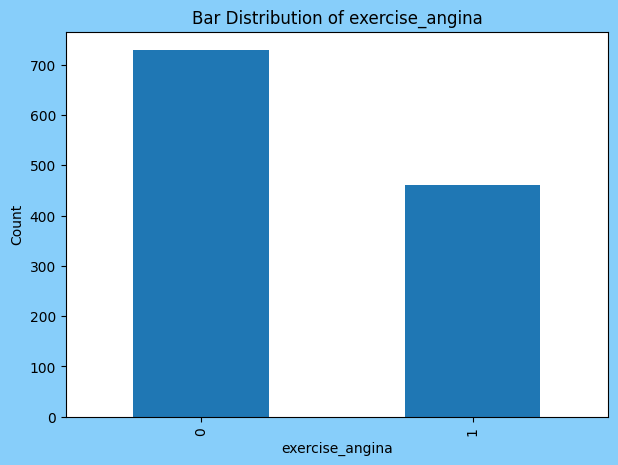

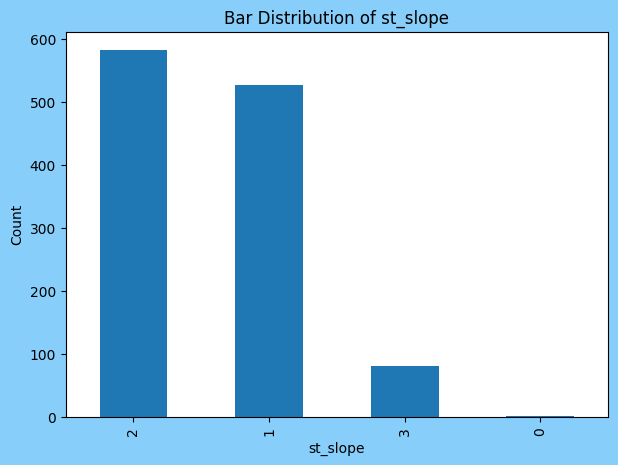

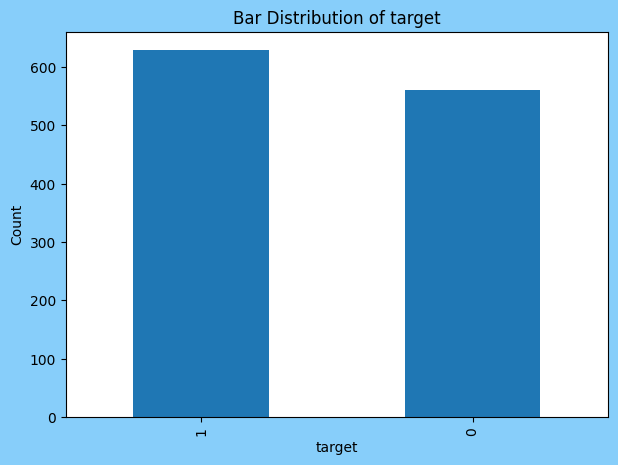

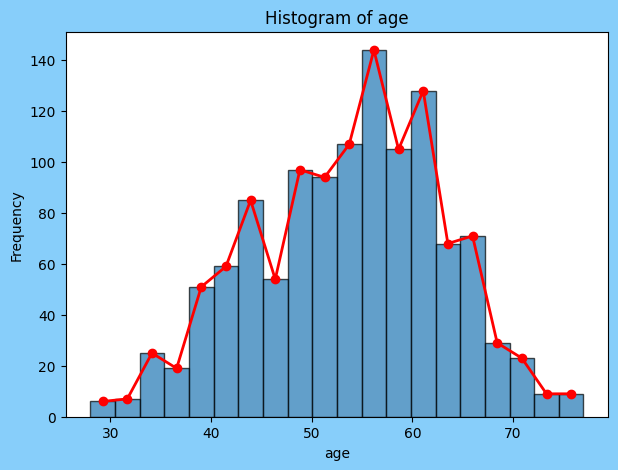

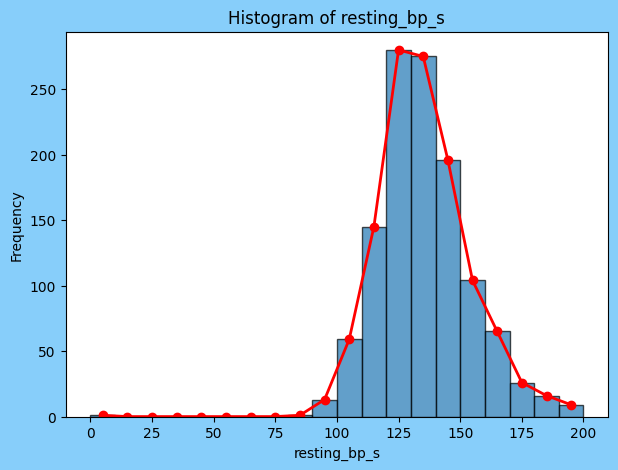

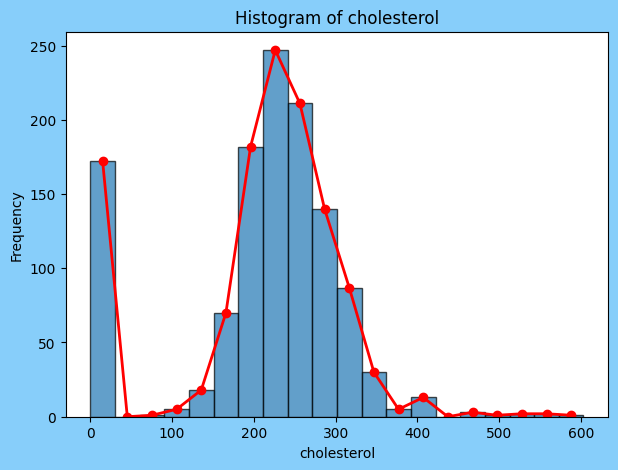

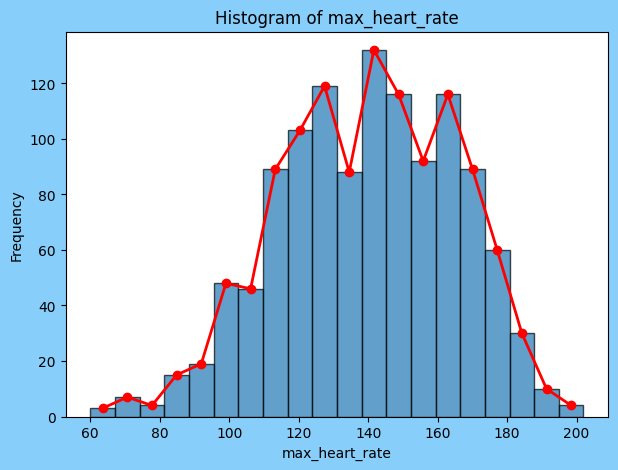

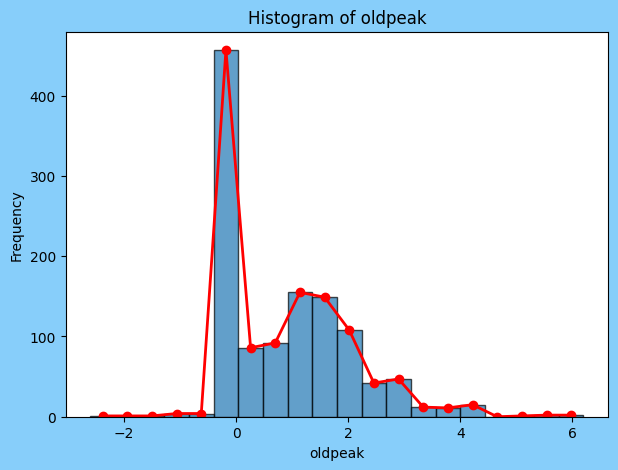

In [12]:
categorical_cols = ['sex', 'chest_pain_type', 'fasting_blood_sugar', 'resting_ecg',
                    'exercise_angina', 'st_slope', 'target']
numerical_cols = ['age', 'resting_bp_s', 'cholesterol', 'max_heart_rate', 'oldpeak']

for col in categorical_cols:
    plot_dist(data, col)

for col in numerical_cols:
    plot_hist(data, col)

In [13]:
def plot_correlation(df, numerical_cols, target=None):
    """
    plots a correlation heatmap for numerical columns
    """
    cols = numerical_cols + [target] if target and target not in numerical_cols else numerical_cols
    corr_matrix = df[cols].corr()

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
                square=True, linewidths=0.5, ax=ax)
    plt.title("Correlation Heatmap")
    plt.show()

    return corr_matrix


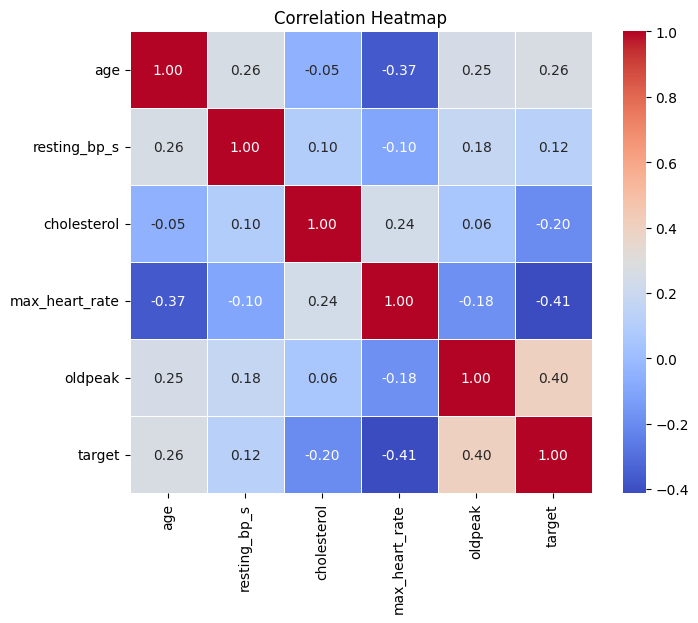

In [14]:
corr_matrix = plot_correlation(data, numerical_cols, target='target')

### Key Insights
- The data is imbalanced in the "Sex" and "fasting_blood_sugar" column


# Phase 3: Data Preprocessing

Based on the EDA above, we handle each flagged issue explicitly:

1. **Duplicates** — dropped, since they inflate any row that happens to repeat and can leak the same patient into both train and test folds.
2. **Placeholder zeros in `cholesterol` and `resting_bp_s` ** — converted to `NaN`, then imputed (median), rather than treated as real low readings.
3. **`st_slope == 0`** — checked against the target rate above; if it behaves like a distinct, meaningful group (not just noise) we keep it as its own category rather than merging it away or dropping those rows outright, since 1,190 rows gives us enough data to support an extra category (unlike the 18-row `thal` case in the Cleveland dataset, where merging was the safer call).

In [19]:
def drop_duplicates(df):
    """
    drops exact duplicate rows
    """
    before = len(df)
    df = df.drop_duplicates().reset_index(drop=True)
    after = len(df)
    print(f"Dropped {before - after} duplicate rows ({before} -> {after})")
    return df


def handle_placeholder_zeros(df):
    """
    converts physiologically impossible zero values (cholesterol, resting_bp_s)
    into NaN, then imputes with the median
    """
    df = df.copy()
    for col in ['cholesterol', 'resting_bp_s']:
        n_zero = (df[col] == 0).sum()
        if n_zero > 0:
            df[col] = df[col].replace(0, np.nan)
            median_val = df[col].median()
            df[col] = df[col].fillna(median_val)
            print(f"{col}: replaced {n_zero} placeholder zeros with median ({median_val:.1f})")
    return df


def encode_st_slope(df, keep_zero_category= True):
    """
    handles the undocumented st_slope == 0 category.
    If keep_zero_category=True, 0 is kept as its own group (e.g. 'unknown/other'),
    since with ~1,190 rows there is likely enough support to keep it distinct
    rather than forcing it into an existing bucket.
    """
    df = df.copy()
    if keep_zero_category:
        df['st_slope_grouped'] = df['st_slope'].map({
            0: 'unknown',
            1: 'upsloping',
            2: 'flat',
            3: 'downsloping'
        })
    else:
        # fallback: treat 0 as missing and impute with the mode
        df['st_slope'] = df['st_slope'].replace(0, np.nan)
        df['st_slope'] = df['st_slope'].fillna(df['st_slope'].mode()[0])
        df['st_slope_grouped'] = df['st_slope'].map({
            1: 'upsloping',
            2: 'flat',
            3: 'downsloping'
        })
    return df


def bin_encode_age_group(df):
    """
    bins age into clinically meaningful groups and then 
    one-hot encodes the age_group column into separate binary columns
    """
    df['age_group'] = pd.cut(df['age'], bins=[0, 40, 55, 65, 100], labels=['under_40', '40_55', '55_65', 'over_65'])

    return df


def encode_categoricals(df):
    """
    one-hot encodes chest_pain_type, resting_ecg, and st_slope_grouped
    (multi-category nominal features with no inherent order)
    """
    df = df.copy()
    dummies = pd.get_dummies(
        df[['chest_pain_type', 'resting_ecg', 'st_slope_grouped', 'age_group']].astype(str),
        prefix=['cp', 'ecg', 'slope','age'],
        drop_first=True).astype(int)
    df = pd.concat([df, dummies], axis=1)
    return df


def clean_data(df, cols_to_drop=None):
    """
    runs the full cleaning and preprocessing pipeline for the comprehensive dataset
    (no scaling here -- scaling is fit per fold/split later to avoid leakage)
    """
    df = df.copy()
    
    print(f"{'*'*30} Dropping duplicate rows{'*'*30}")
    df = drop_duplicates(df)
    print("Done")
    
    print(f"{'*'*30} Handling placeholder zeros{'*'*30}")
    df = handle_placeholder_zeros(df)
    print("Done")
    
    print(f"{'*'*30} Encoding st slope{'*'*30}")
    df = encode_st_slope(df, keep_zero_category=False)
    print("Done")
    
    print(f"{'*'*30}Binning and Encoding Age column{'*'*30}")
    df = bin_encode_age_group(df)
    print("Done")
    
    print(f"{'*'*30} Encoding categorical columns{'*'*30}")
    df = encode_categoricals(df)
    print("Done")

    if cols_to_drop is None:
        cols_to_drop = ['chest_pain_type', 'resting_ecg', 'st_slope', 'st_slope_grouped','age_group']
    
    print(f"{'*'*30} Droping columns{'*'*30}")
    df = df.drop(columns=cols_to_drop)
    print("Done")

    return df

In [20]:
df_clean = clean_data(data)
print(df_clean.shape)
df_clean.head()

****************************** Dropping duplicate rows******************************
Dropped 272 duplicate rows (1190 -> 918)
Done
****************************** Handling placeholder zeros******************************
cholesterol: replaced 172 placeholder zeros with median (237.0)
resting_bp_s: replaced 1 placeholder zeros with median (130.0)
Done
****************************** Encoding st slope******************************
Done
******************************Binning and Encoding Age column******************************
Done
****************************** Encoding categorical columns******************************
Done
****************************** Droping columns******************************
Done
(918, 19)


,age,sex,resting_bp_s,cholesterol,fasting_blood_sugar,max_heart_rate,exercise_angina,oldpeak,target,cp_2,cp_3,cp_4,ecg_1,ecg_2,slope_flat,slope_upsloping,age_55_65,age_over_65,age_under_40
0,40,1,140.0,289.0,0,172,0,0.0,0,1,0,0,0,0,0,1,0,0,1
1,49,0,160.0,180.0,0,156,0,1.0,1,0,1,0,0,0,1,0,0,0,0
2,37,1,130.0,283.0,0,98,0,0.0,0,1,0,0,1,0,0,1,0,0,1
3,48,0,138.0,214.0,0,108,1,1.5,1,0,0,1,0,0,1,0,0,0,0
4,54,1,150.0,195.0,0,122,0,0.0,0,0,1,0,0,0,0,1,0,0,0


In [21]:
# quick sanity check: confirm no zero-cholesterol / zero-bp rows remain, and no duplicates
print("Remaining cholesterol zeros:", (df_clean['cholesterol'] == 0).sum())
print("Remaining resting_bp_s zeros:", (df_clean['resting_bp_s'] == 0).sum())
print("Remaining duplicate rows:", df_clean.duplicated().sum())

Remaining cholesterol zeros: 0
Remaining resting_bp_s zeros: 0
Remaining duplicate rows: 0


In [22]:
y = df_clean['target']
X = df_clean.drop(columns=['target'])

print(X.shape, y.shape)

(918, 18) (918,)


# Phase 4: Model Fitting and Evaluation

We use Stratified K-Fold cross-validation, scaling fit inside each fold to avoid leakage, class-imbalance handling via sample weights / `class_weight`, and the same three models (Logistic Regression, Random Forest, XGBoost).

In [23]:
numerical_cols = ['age', 'resting_bp_s', 'cholesterol', 'max_heart_rate', 'oldpeak']

stkf = StratifiedKFold(n_splits=5, shuffle=True, random_state=43)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=4, class_weight='balanced', random_state=43),
    'XGBoost': xgb.XGBClassifier(
        tree_method="hist",
        max_depth=3,
        n_estimators=100,
        learning_rate=0.05,
        reg_lambda=1.0,
        random_state=43
    )
}

# store metrics per model
all_results = {}

for model_name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Model: {model_name}")
    print('='*50)

    fold_metrics = {
        'balanced_accuracy': [],
        'f1': [],
        'roc_auc': [],
        'precision': [],
        'recall': []
    }

    for fold_num, (train_index, test_index) in enumerate(stkf.split(X, y), start=1):
        X_train_fold, X_test_fold = X.iloc[train_index].copy(), X.iloc[test_index].copy()
        y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

        # scale INSIDE the fold - fit on train, transform on test only
        scaler = RobustScaler()
        X_train_fold[numerical_cols] = scaler.fit_transform(X_train_fold[numerical_cols])
        X_test_fold[numerical_cols] = scaler.transform(X_test_fold[numerical_cols])

        weights = compute_sample_weight(class_weight="balanced", y=y_train_fold)

        if model_name == 'XGBoost':
            model.fit(X_train_fold, y_train_fold, sample_weight=weights)
        else:
            model.fit(X_train_fold, y_train_fold)

        y_pred_fold = model.predict(X_test_fold)
        y_proba_fold = model.predict_proba(X_test_fold)[:, 1]

        fold_metrics['balanced_accuracy'].append(balanced_accuracy_score(y_test_fold, y_pred_fold))
        fold_metrics['f1'].append(f1_score(y_test_fold, y_pred_fold))
        fold_metrics['roc_auc'].append(roc_auc_score(y_test_fold, y_proba_fold))
        fold_metrics['precision'].append(precision_score(y_test_fold, y_pred_fold))
        fold_metrics['recall'].append(recall_score(y_test_fold, y_pred_fold))

        print(f"Fold {fold_num}: bal_acc={fold_metrics['balanced_accuracy'][-1]:.4f}, "
              f"f1={fold_metrics['f1'][-1]:.4f}, roc_auc={fold_metrics['roc_auc'][-1]:.4f}")

    print(f"\n--- {model_name} Summary ---")
    for metric_name, scores in fold_metrics.items():
        print(f"{metric_name}: {np.mean(scores):.4f} \u00b1 {np.std(scores):.4f}")

    all_results[model_name] = fold_metrics

print(f"\n{'='*50}")
print("FINAL MODEL COMPARISON (mean \u00b1 std)")
print('='*50)
for model_name, fold_metrics in all_results.items():
    print(f"\n{model_name}:")
    for metric_name, scores in fold_metrics.items():
        print(f"  {metric_name}: {np.mean(scores):.4f} \u00b1 {np.std(scores):.4f}")


Model: Logistic Regression
Fold 1: bal_acc=0.8533, f1=0.8657, roc_auc=0.8942
Fold 2: bal_acc=0.8693, f1=0.8910, roc_auc=0.9417
Fold 3: bal_acc=0.8265, f1=0.8517, roc_auc=0.8930
Fold 4: bal_acc=0.8747, f1=0.8844, roc_auc=0.9451
Fold 5: bal_acc=0.8366, f1=0.8485, roc_auc=0.9234

--- Logistic Regression Summary ---
balanced_accuracy: 0.8521 ± 0.0185
f1: 0.8682 ± 0.0170
roc_auc: 0.9195 ± 0.0224
precision: 0.8674 ± 0.0217
recall: 0.8700 ± 0.0298

Model: Random Forest
Fold 1: bal_acc=0.8362, f1=0.8515, roc_auc=0.9010
Fold 2: bal_acc=0.8375, f1=0.8612, roc_auc=0.9324
Fold 3: bal_acc=0.8265, f1=0.8517, roc_auc=0.9053
Fold 4: bal_acc=0.8762, f1=0.8932, roc_auc=0.9504
Fold 5: bal_acc=0.8526, f1=0.8643, roc_auc=0.9267

--- Random Forest Summary ---
balanced_accuracy: 0.8458 ± 0.0173
f1: 0.8644 ± 0.0153
roc_auc: 0.9232 ± 0.0182
precision: 0.8573 ± 0.0184
recall: 0.8721 ± 0.0240

Model: XGBoost
Fold 1: bal_acc=0.8618, f1=0.8673, roc_auc=0.9168
Fold 2: bal_acc=0.8595, f1=0.8804, roc_auc=0.9470
Fold

In [24]:
# 1. Check the actual imbalance
"""
Notice that the data is severly imbalanced in the sex column we are checking if it disturbs the model performance, particularly recall for 
disease-positive cases, was lower for female patients across cross-validation folds, 
likely reflecting the ~76/24 male/female split in the training data. This suggests 
the model's clinical utility may be less reliable for female patients, and a production system would need either more 
balanced female representation in training data or sex-stratified model calibration before deployment.
"""
print(data['sex'].value_counts(normalize=True))

# 2. Check subgroup performance after training — evaluate metrics separately by sex
from sklearn.metrics import classification_report

for sex_val, label in [(1, 'Male'), (0, 'Female')]:
    mask = X_test_fold['sex'] == sex_val
    if mask.sum() > 0:
        print(f"\n--- {label} (n={mask.sum()}) ---")
        print(classification_report(y_test_fold[mask], y_pred_fold[mask]))

sex
1    0.763866
0    0.236134
Name: proportion, dtype: float64

--- Male (n=148) ---
              precision    recall  f1-score   support

           0       0.80      0.82      0.81        57
           1       0.89      0.87      0.88        91

    accuracy                           0.85       148
   macro avg       0.84      0.85      0.84       148
weighted avg       0.85      0.85      0.85       148


--- Female (n=35) ---
              precision    recall  f1-score   support

           0       0.81      0.88      0.85        25
           1       0.62      0.50      0.56        10

    accuracy                           0.77        35
   macro avg       0.72      0.69      0.70        35
weighted avg       0.76      0.77      0.76        35



# Phase 5: Light Hyperparameter Tuning 


In [25]:
# optuna uses bayesian optimization to determine the best parameters to use so its best for this tuning 
# where we are concious of our data size and want to limit overfiting

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 400, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 6),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
    }

    pipe = Pipeline([
        ('scaler', RobustScaler()),
        ('model', RandomForestClassifier(**params, class_weight='balanced', random_state=43))
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=43)
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='balanced_accuracy', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=43))
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"Best balanced accuracy (CV mean): {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

  0%|          | 0/30 [00:00<?, ?it/s]

Best balanced accuracy (CV mean): 0.8632
Best params: {'n_estimators': 400, 'max_depth': 7, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'sqrt'}


# Phase 6: Final Fitting and Saving of the model

In [26]:
# used Random Forest classifier has its not as simple as LogisticRegression and also not as complex as XGBoost
final_model = RandomForestClassifier(n_estimators = 400, max_depth = 7, min_samples_split =  3, min_samples_leaf =  1, max_features =  'sqrt',
                                     class_weight='balanced', random_state=43)

final_model.fit(X,y)

# Saving the model using joblib 
joblib.dump(final_model, 'random_forest_model.joblib')

#Pls note that if you want to share models it is not advisable to use pickle or joblib its best to use "Skops"

['random_forest_model.joblib']

In [27]:
"""
to take care of the imbalanced columns we train a balancedbaggingclassifier
"""
# --- 1. Define the base estimator using your tuned Random Forest parameters ---
base_rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=7,
    min_samples_split=3,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=43
    # note: no class_weight='balanced' here -- BalancedBaggingClassifier
    # handles the class imbalance itself via undersampling each bootstrap
    # sample, so combining both is redundant (and can over-correct)
)

balanced_bagging_model = BalancedBaggingClassifier(
    estimator=base_rf,          # use base_estimator=base_rf instead if you're on an older imblearn version
    n_estimators=10,            # number of bagged RF's (each trained on a balanced resample)
    sampling_strategy='auto',   # undersamples the majority class to match the minority class per bag
    random_state=43,
    n_jobs=-1
)

# --- 2. Small CV check before committing to a full fit ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=43)

cv_results = cross_validate(
    balanced_bagging_model, X, y, cv=cv,
    scoring=['balanced_accuracy', 'f1', 'roc_auc', 'precision', 'recall'],
    n_jobs=-1
)

print("--- BalancedBaggingClassifier CV Results ---")
for metric in ['balanced_accuracy', 'f1', 'roc_auc', 'precision', 'recall']:
    scores = cv_results[f'test_{metric}']
    print(f"{metric}: {scores.mean():.4f} ± {scores.std():.4f}")

# --- 3. Fit on full data and save ---
balanced_bagging_model.fit(X, y)

save_path = os.path.join(os.getcwd(), 'balanced_bagging_rf_model.joblib')
joblib.dump(balanced_bagging_model, save_path)
print(f"\nSaved to: {save_path}")

--- BalancedBaggingClassifier CV Results ---
balanced_accuracy: 0.8592 ± 0.0154
f1: 0.8758 ± 0.0138
roc_auc: 0.9295 ± 0.0182
precision: 0.8709 ± 0.0223
recall: 0.8819 ± 0.0294

Saved to: /kaggle/working/balanced_bagging_rf_model.joblib


# model performance
- the model has a balanced accuracy of 0.8548 -  the average of recall obtained on each class.
- it has an f1 of 0.87 this is good because F1 score can be interpreted as a harmonic mean of the precision and recall
- it has a precision of 0.86 (The precision is intuitively the ability of the classifier not to label as positive a sample that is negative.)
- it has a recall of 0.87 (The recall is intuitively the ability of the classifier to find all the positive samples.)